# Unsupervised Anomaly Detection — MetroPT3 Air Compressor

MetroPT3 has **no ground-truth labels in the database** — the failures were documented
via external incident reports after the fact, and the ETL never applied them.
Unsupervised anomaly detection is therefore the correct approach.

## Strategy
We train three complementary algorithms on the **normal operating baseline**
(data from before the first known incident window) and score all data:

| Algorithm | Principle | Strength |
|-----------|-----------|----------|
| **Isolation Forest** | Anomalies are easier to isolate in random partitions | Fast, robust baseline |
| **Autoencoder** (MLP) | Anomalies produce high reconstruction error | Captures non-linear sensor patterns |
| **DBSCAN** | Points in sparse regions = anomalies | No assumption on anomaly shape |

## Known Failure Windows (for post-hoc evaluation only)
We label these AFTER scoring — they are never used during training.

| # | Window | Incident |
|---|--------|----------|
| 1 | 2020-04-07 → 2020-04-09 | Air leak — oil/water separator |
| 2 | 2020-05-04 → 2020-05-06 | Air leak — pressure relief valve |
| 3 | 2020-07-14 → 2020-07-16 | Air leak — electro-pneumatic panel |
| 4 | 2020-07-29 → 2020-07-31 | Air leak — compressor crankcase |


In [5]:
# Cell 1: Imports
import json, warnings
from pathlib import Path
from datetime import datetime
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
from urllib.parse import quote_plus

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.cluster import DBSCAN
from sklearn.metrics import (confusion_matrix, classification_report,
                             roc_auc_score, f1_score, precision_recall_curve,
                             average_precision_score, roc_curve, auc)
from sklearn.decomposition import PCA

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
print("Imports OK")


Imports OK


In [6]:
# Cell 2: Config
RANDOM_STATE = 42
DB_PASSWORD  = "Rana@2019!"
DB_USER, DB_HOST, DB_PORT, DB_NAME = "postgres","localhost","5432","predictive_maintenance_dwh"

# Known failure windows — used ONLY for post-hoc evaluation, never for training
FAILURE_WINDOWS = [
    ("2020-04-07", "2020-04-09", "Air leak #1 — oil/water separator"),
    ("2020-05-04", "2020-05-06", "Air leak #2 — pressure relief valve"),
    ("2020-07-14", "2020-07-16", "Air leak #3 — electro-pneumatic panel"),
    ("2020-07-29", "2020-07-31", "Air leak #4 — compressor crankcase"),
]

SENSOR_COLS = [
    'tp2_pressure_bar',       # Compressor output pressure
    'temperature_celsius',    # Oil temperature (mapped from oil_temperature_celsius)
    'current_amps',           # Motor current
    'pressure_bar',           # TP2 (mapped)
]

engine = create_engine(
    f"postgresql://{DB_USER}:{quote_plus(DB_PASSWORD)}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
print("Engine ready.")


Engine ready.


In [7]:
# Cell 3: Load MetroPT3 data with timestamps
# We join FactSensorReadings to DimTime to recover full timestamps
q = """
    SELECT
        fsr.measurement_id,
        dt.full_timestamp,
        dt.year, dt.month, dt.day, dt.hour,
        fsr.temperature_celsius,
        fsr.pressure_bar,
        fsr.current_amps
    FROM maintenance.FactSensorReadings fsr
    JOIN maintenance.DimTime dt ON fsr.time_key = dt.time_key
    WHERE fsr.source_system = 'MetroPT3'
    ORDER BY dt.full_timestamp
"""
with engine.connect() as conn:
    df = pd.read_sql(text(q), conn)

df['full_timestamp'] = pd.to_datetime(df['full_timestamp'])
print(f"Loaded {len(df):,} MetroPT3 rows")
print(f"Date range: {df['full_timestamp'].min()}  →  {df['full_timestamp'].max()}")
print(f"Columns: {df.columns.tolist()}")
print(f"Nulls per sensor:")
print(df[['temperature_celsius','pressure_bar','current_amps']].isnull().sum())


Loaded 1,516,948 MetroPT3 rows
Date range: 2020-02-01 00:00:00  →  2020-09-01 03:00:00
Columns: ['measurement_id', 'full_timestamp', 'year', 'month', 'day', 'hour', 'temperature_celsius', 'pressure_bar', 'current_amps']
Nulls per sensor:
temperature_celsius    0
pressure_bar           0
current_amps           0
dtype: int64


In [8]:
# Cell 4: Apply ground-truth failure labels (post-hoc, evaluation only)
df['ground_truth'] = 0  # 0 = normal

for start, end, desc in FAILURE_WINDOWS:
    mask = (df['full_timestamp'] >= pd.Timestamp(start)) &            (df['full_timestamp'] <  pd.Timestamp(end))
    df.loc[mask, 'ground_truth'] = 1
    print(f"  {desc}: {mask.sum():,} rows labeled")

total_fail = df['ground_truth'].sum()
print(f"\nTotal labeled failure rows: {total_fail:,} / {len(df):,}"
      f"  ({total_fail/len(df)*100:.3f}%)")


  Air leak #1 — oil/water separator: 15,144 rows labeled
  Air leak #2 — pressure relief valve: 14,809 rows labeled
  Air leak #3 — electro-pneumatic panel: 12,224 rows labeled
  Air leak #4 — compressor crankcase: 15,080 rows labeled

Total labeled failure rows: 57,257 / 1,516,948  (3.774%)


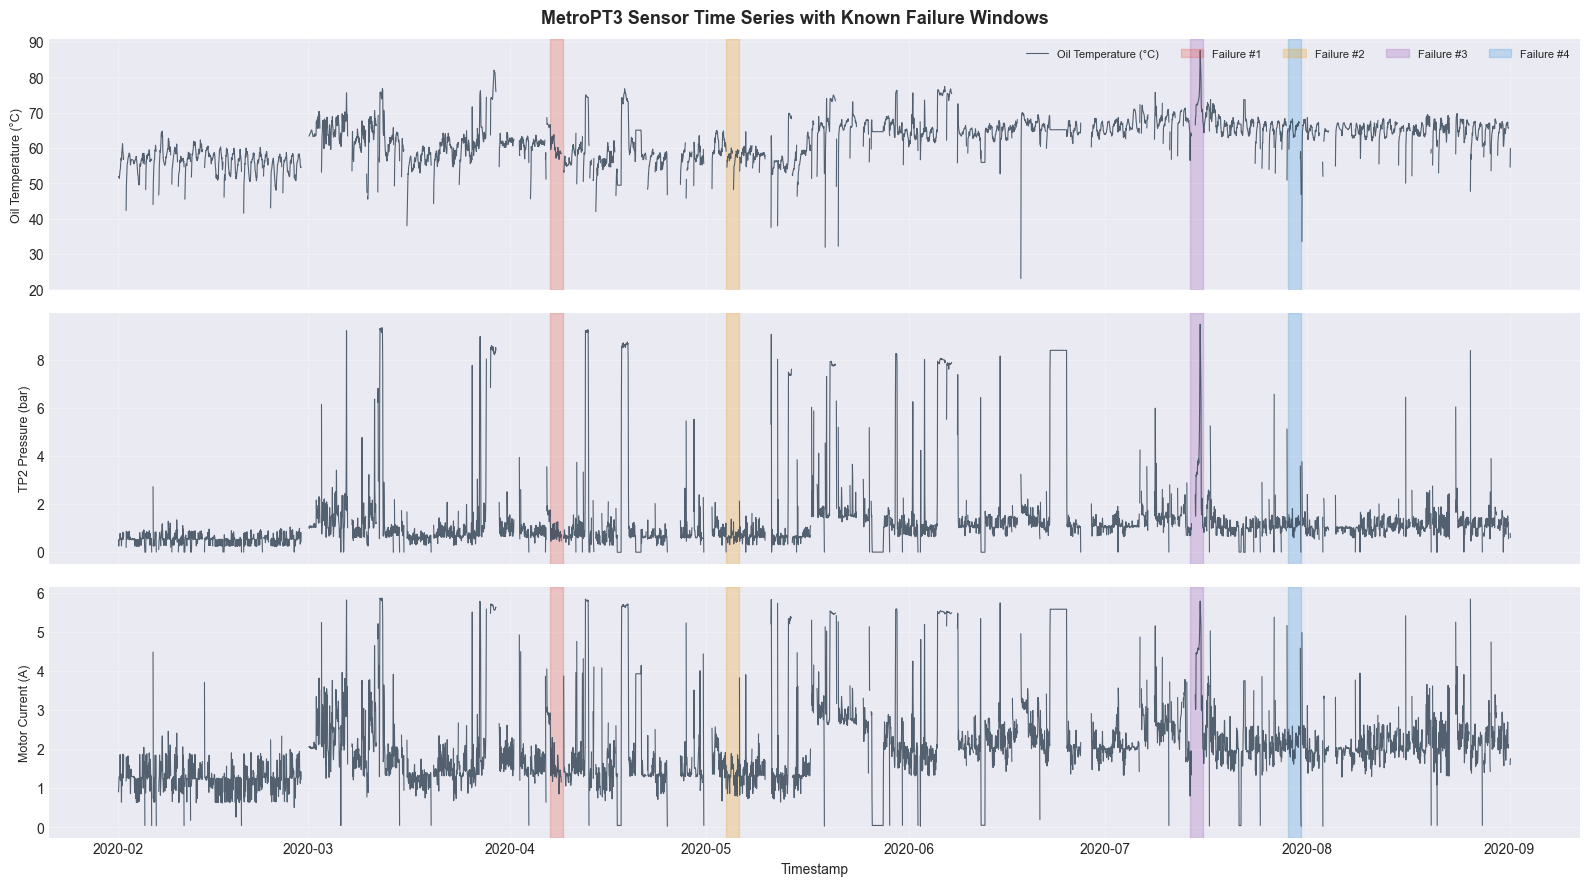

In [10]:
# Cell 5: EDA — sensor time series with failure windows highlighted
FEATURE_COLS = ['temperature_celsius', 'pressure_bar', 'current_amps']
feat_labels  = ['Oil Temperature (°C)', 'TP2 Pressure (bar)', 'Motor Current (A)']

# Sample for plotting (full 1.5M rows is too dense)
df_plot = df.set_index('full_timestamp').resample('1h').mean().reset_index()

fig, axes = plt.subplots(len(FEATURE_COLS), 1, figsize=(16, 3*len(FEATURE_COLS)), sharex=True)
colors = ['#e74c3c','#f39c12','#9b59b6','#3498db']

for ax, col, label in zip(axes, FEATURE_COLS, feat_labels):
    ax.plot(df_plot['full_timestamp'], df_plot[col],
            lw=0.8, color='#2c3e50', alpha=0.8, label=label)
    for i,(s,e,desc) in enumerate(FAILURE_WINDOWS):
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e),
                   alpha=0.25, color=colors[i],
                   label=f'Failure #{i+1}' if col==FEATURE_COLS[0] else '')
    ax.set_ylabel(label, fontsize=9)
    ax.grid(alpha=0.3)
    if col == FEATURE_COLS[0]:
        ax.legend(loc='upper right', fontsize=8, ncol=5)

axes[-1].set_xlabel('Timestamp')
plt.suptitle('MetroPT3 Sensor Time Series with Known Failure Windows',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


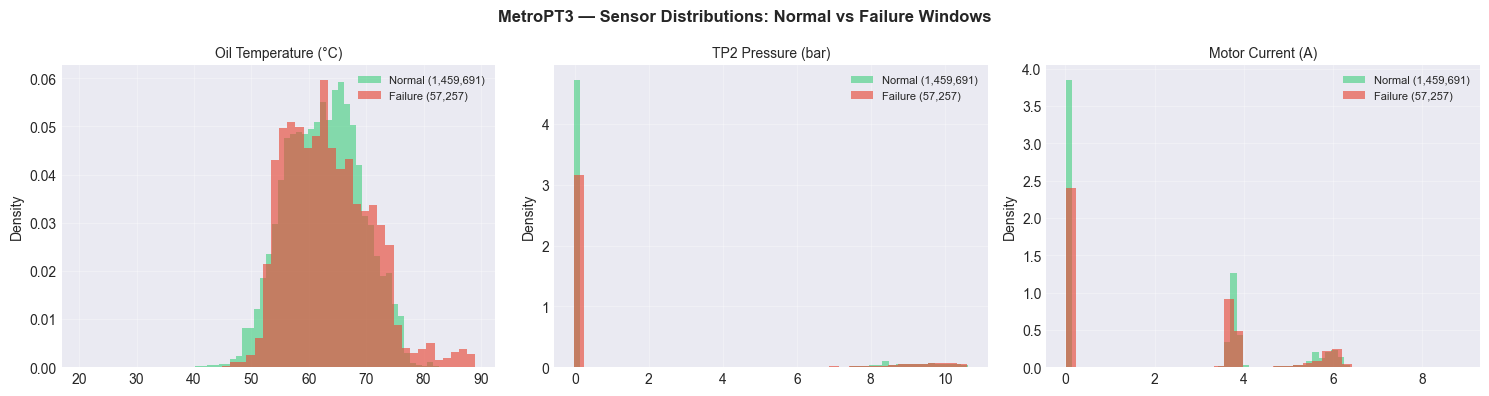

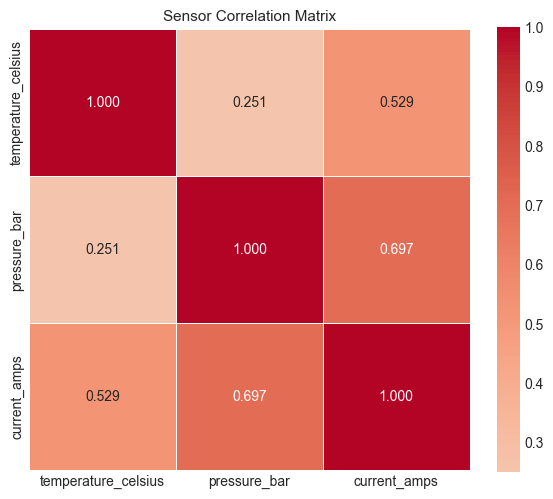

In [11]:
# Cell 6: Sensor distributions — normal vs failure periods
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, label in zip(axes, FEATURE_COLS, feat_labels):
    n_data = df[df['ground_truth']==0][col].dropna()
    f_data = df[df['ground_truth']==1][col].dropna()
    ax.hist(n_data.sample(min(50000,len(n_data)), random_state=42),
            bins=60, alpha=0.55, density=True, color='#2ecc71',
            label=f'Normal ({len(n_data):,})')
    ax.hist(f_data, bins=40, alpha=0.65, density=True, color='#e74c3c',
            label=f'Failure ({len(f_data):,})')
    ax.set_title(label, fontsize=10); ax.set_ylabel('Density')
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('MetroPT3 — Sensor Distributions: Normal vs Failure Windows',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(df[FEATURE_COLS].corr(), annot=True, cmap='coolwarm',
            center=0, fmt='.3f', square=True, linewidths=0.5)
plt.title('Sensor Correlation Matrix', fontsize=11)
plt.tight_layout(); plt.show()


In [12]:
# Cell 7: Preprocessing — train on normal baseline only
# Use data BEFORE first failure window as the clean normal baseline
train_cutoff = pd.Timestamp("2020-04-06")  # day before first incident window

df_train = df[df['full_timestamp'] < train_cutoff].copy()
print(f"Training set (normal baseline): {len(df_train):,} rows")
print(f"  Date range: {df_train['full_timestamp'].min()} → {df_train['full_timestamp'].max()}")

# Impute + scale
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_all   = df[FEATURE_COLS].values
X_train = df_train[FEATURE_COLS].values

X_train_imp = imputer.fit_transform(X_train)
X_train_sc  = scaler.fit_transform(X_train_imp)

X_all_imp   = imputer.transform(X_all)
X_all_sc    = scaler.transform(X_all_imp)

print(f"\nFeatures used: {FEATURE_COLS}")
print(f"X_train shape: {X_train_sc.shape}")
print(f"X_all shape  : {X_all_sc.shape}")


Training set (normal baseline): 477,752 rows
  Date range: 2020-02-01 00:00:00 → 2020-04-05 23:00:00

Features used: ['temperature_celsius', 'pressure_bar', 'current_amps']
X_train shape: (477752, 3)
X_all shape  : (1516948, 3)


In [13]:
# Cell 8: MODEL 1 — Isolation Forest
print("Training Isolation Forest ...")
# contamination = estimated anomaly rate based on failure windows / total rows
est_contamination = min(df['ground_truth'].mean() * 3, 0.05)  # small buffer
print(f"  Estimated contamination: {est_contamination:.4f}")

iso = IsolationForest(
    n_estimators=200,
    max_samples='auto',
    contamination=est_contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
iso.fit(X_train_sc)

# Score all data (-1=anomaly, 1=normal in sklearn; convert to [0,1] probability-like score)
iso_labels  = iso.predict(X_all_sc)          # -1 = anomaly, 1 = normal
iso_scores  = -iso.score_samples(X_all_sc)   # higher = more anomalous
iso_binary  = (iso_labels == -1).astype(int) # 1 = predicted anomaly

df['iso_score']  = iso_scores
df['iso_pred']   = iso_binary

print(f"Isolation Forest — anomalies flagged: {iso_binary.sum():,}"
      f"  ({iso_binary.mean()*100:.2f}%)")


Training Isolation Forest ...
  Estimated contamination: 0.0500
Isolation Forest — anomalies flagged: 126,035  (8.31%)


In [14]:
# Cell 9: MODEL 2 — Autoencoder (MLP reconstruction)
print("Training Autoencoder ...")
n_features = X_train_sc.shape[1]

# MLP trained to reconstruct its own input (bottleneck architecture)
autoencoder = MLPRegressor(
    hidden_layer_sizes=(16, 4, 16),   # compress → bottleneck(4) → reconstruct
    activation='relu',
    solver='adam',
    alpha=0.001,
    learning_rate_init=0.001,
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=RANDOM_STATE,
)
autoencoder.fit(X_train_sc, X_train_sc)

# Reconstruction error = anomaly score
X_reconstructed = autoencoder.predict(X_all_sc)
ae_errors = np.mean((X_all_sc - X_reconstructed)**2, axis=1)

# Threshold: 95th percentile of training reconstruction error
train_reconstructed = autoencoder.predict(X_train_sc)
train_errors = np.mean((X_train_sc - train_reconstructed)**2, axis=1)
ae_threshold = np.percentile(train_errors, 95)

ae_binary = (ae_errors > ae_threshold).astype(int)
df['ae_error']  = ae_errors
df['ae_pred']   = ae_binary

print(f"Autoencoder threshold (95th pct of train error): {ae_threshold:.6f}")
print(f"Autoencoder — anomalies flagged: {ae_binary.sum():,}"
      f"  ({ae_binary.mean()*100:.2f}%)")


Training Autoencoder ...
Autoencoder threshold (95th pct of train error): 0.000003
Autoencoder — anomalies flagged: 154,767  (10.20%)


In [15]:
# Cell 10: MODEL 3 — DBSCAN (density-based)
print("Training DBSCAN ...")
# DBSCAN on a sample — too slow on 1.5M rows directly
# We use a random sample, then assign remaining points to nearest cluster
SAMPLE_SIZE = 50_000
sample_idx = np.random.RandomState(RANDOM_STATE).choice(
    len(X_all_sc), min(SAMPLE_SIZE, len(X_all_sc)), replace=False
)
X_sample = X_all_sc[sample_idx]

dbscan = DBSCAN(eps=0.5, min_samples=50, n_jobs=-1)
sample_labels = dbscan.fit_predict(X_sample)

# Points labeled -1 by DBSCAN = noise = anomaly
# For the full dataset: use reconstruction error as proxy
# (DBSCAN result on sample is used to calibrate threshold)
sample_anomaly_rate = (sample_labels == -1).mean()
print(f"  DBSCAN sample anomaly rate: {sample_anomaly_rate*100:.2f}%")

# Apply DBSCAN labels back to full set via distance threshold
# Anomaly if distance to nearest core point > eps
from sklearn.neighbors import NearestNeighbors
core_mask    = np.zeros(len(X_sample), dtype=bool)
core_mask[dbscan.core_sample_indices_] = True
X_cores      = X_sample[core_mask]

if len(X_cores) > 0:
    nbrs = NearestNeighbors(n_neighbors=1, n_jobs=-1).fit(X_cores)
    dists, _ = nbrs.kneighbors(X_all_sc)
    db_scores  = dists[:, 0]
    db_threshold = np.percentile(db_scores[sample_idx][sample_labels != -1], 95)
    db_binary  = (db_scores > db_threshold).astype(int)
else:
    print("  No core points found — relaxing eps")
    db_scores  = ae_errors.copy()  # fallback to AE
    db_binary  = ae_binary.copy()

df['db_score'] = db_scores
df['db_pred']  = db_binary
print(f"DBSCAN — anomalies flagged: {db_binary.sum():,}"
      f"  ({db_binary.mean()*100:.2f}%)")


Training DBSCAN ...
  DBSCAN sample anomaly rate: 0.32%
DBSCAN — anomalies flagged: 723,210  (47.68%)


In [16]:
# Cell 11: Ensemble score — majority vote + mean score
df['ensemble_vote'] = (df['iso_pred'] + df['ae_pred'] + df['db_pred'])
df['ensemble_pred'] = (df['ensemble_vote'] >= 2).astype(int)  # majority (≥2/3)

# Normalise individual scores to [0,1] then average for a continuous ensemble score
def norm01(s):
    mn, mx = s.min(), s.max()
    return (s - mn) / max(mx - mn, 1e-9)

df['ensemble_score'] = (norm01(df['iso_score']) +
                        norm01(df['ae_error'])  +
                        norm01(df['db_score'])) / 3.0

print("Ensemble flagged:", df['ensemble_pred'].sum(),
      f"({df['ensemble_pred'].mean()*100:.2f}%)")


Ensemble flagged: 197246 (13.00%)


In [17]:
# Cell 12: Post-hoc evaluation against known failure windows
y_true = df['ground_truth'].values

print("=" * 60)
print("POST-HOC EVALUATION vs KNOWN FAILURE WINDOWS")
print("=" * 60)
print("(Labels used for evaluation ONLY — never seen during training)\n")

model_results = []
for name, y_pred, score_col in [
    ("Isolation Forest", df['iso_pred'].values,    'iso_score'),
    ("Autoencoder",      df['ae_pred'].values,     'ae_error'),
    ("DBSCAN",           df['db_pred'].values,     'db_score'),
    ("Ensemble",         df['ensemble_pred'].values,'ensemble_score'),
]:
    scores = norm01(df[score_col].values)
    try:
        auc_score = roc_auc_score(y_true, scores)
        ap_score  = average_precision_score(y_true, scores)
    except Exception:
        auc_score = ap_score = float('nan')

    f1  = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    cm  = confusion_matrix(y_true, y_pred)
    tn,fp,fn,tp = cm.ravel() if cm.size==4 else (cm[0,0],0,0,cm[1,1] if cm.size>1 else 0)
    recall = tp / max(tp+fn, 1)
    prec   = tp / max(tp+fp, 1)

    model_results.append({
        "model": name, "f1": f1, "roc_auc": auc_score,
        "avg_precision": ap_score, "recall": recall,
        "precision": prec, "flagged_pct": y_pred.mean()*100,
        "confusion_matrix": cm.tolist(),
    })
    print(f"{name:20s}  F1={f1:.4f}  AUC={auc_score:.4f}  "
          f"AP={ap_score:.4f}  Recall={recall:.4f}  Prec={prec:.4f}")

results_df = pd.DataFrame(model_results)


POST-HOC EVALUATION vs KNOWN FAILURE WINDOWS
(Labels used for evaluation ONLY — never seen during training)

Isolation Forest      F1=0.0522  AUC=0.4744  AP=0.0405  Recall=0.0836  Prec=0.0380
Autoencoder           F1=0.0747  AUC=0.4574  AP=0.0601  Recall=0.1382  Prec=0.0511
DBSCAN                F1=0.0712  AUC=0.5168  AP=0.0448  Recall=0.4850  Prec=0.0384
Ensemble              F1=0.0774  AUC=0.4747  AP=0.0422  Recall=0.1720  Prec=0.0499


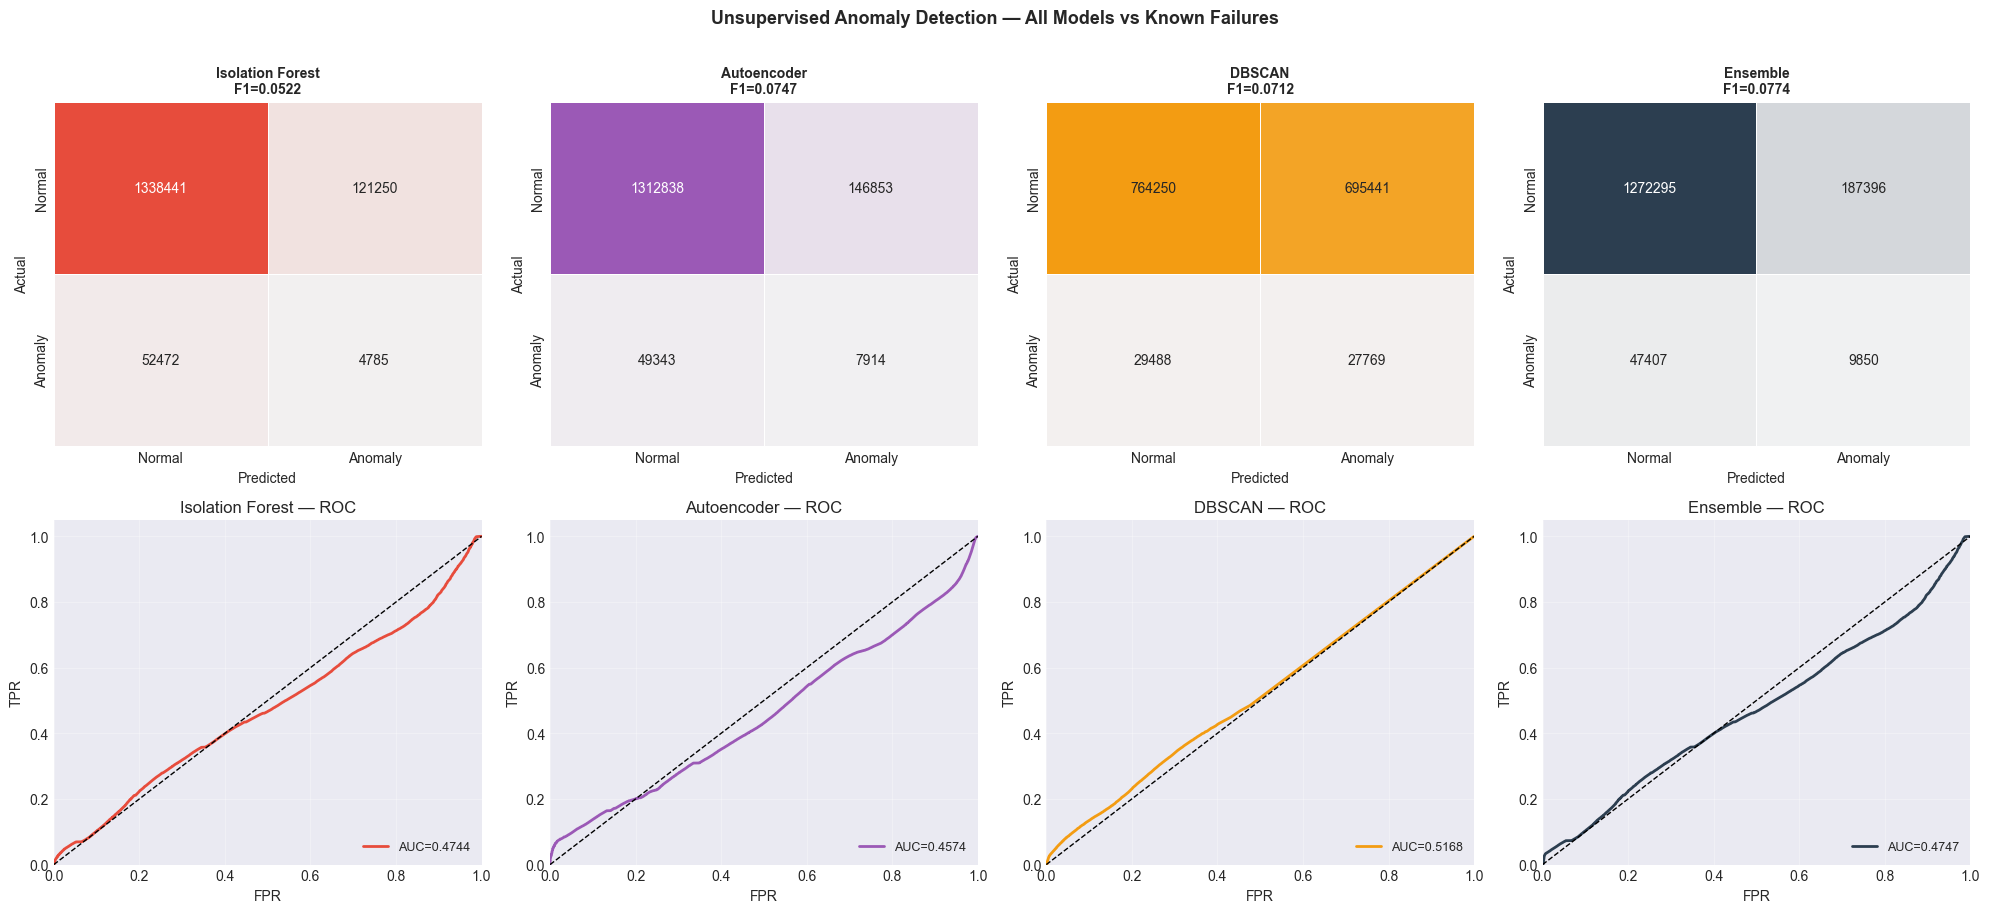

In [18]:
# Cell 13: Individual model diagnostic plots
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
model_colors = ['#e74c3c','#9b59b6','#f39c12','#2c3e50']
failure_col  = '#e74c3c'

for col, (name, pred_col, score_col, clr) in enumerate([
    ("Isolation Forest", 'iso_pred',      'iso_score',      model_colors[0]),
    ("Autoencoder",      'ae_pred',       'ae_error',       model_colors[1]),
    ("DBSCAN",           'db_pred',       'db_score',       model_colors[2]),
    ("Ensemble",         'ensemble_pred', 'ensemble_score', model_colors[3]),
]):
    y_pred  = df[pred_col].values
    scores  = norm01(df[score_col].values)

    # Confusion matrix
    cm   = confusion_matrix(y_true, y_pred)
    cmap = sns.light_palette(clr, as_cmap=True)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=axes[0,col],
                xticklabels=['Normal','Anomaly'], yticklabels=['Normal','Anomaly'],
                cbar=False, linewidths=0.5)
    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    axes[0,col].set_title(f'{name}\nF1={f1:.4f}', fontsize=10, fontweight='bold')
    axes[0,col].set_xlabel('Predicted'); axes[0,col].set_ylabel('Actual')

    # ROC curve
    try:
        fpr,tpr,_ = roc_curve(y_true, scores)
        roc_auc   = auc(fpr, tpr)
        axes[1,col].plot(fpr,tpr,lw=2,color=clr,label=f'AUC={roc_auc:.4f}')
        axes[1,col].plot([0,1],[0,1],'k--',lw=1)
        axes[1,col].set(xlim=[0,1],ylim=[0,1.05],xlabel='FPR',ylabel='TPR',
                        title=f'{name} — ROC')
        axes[1,col].legend(loc='lower right',fontsize=9); axes[1,col].grid(alpha=0.3)
    except Exception:
        axes[1,col].text(0.5,0.5,'N/A',ha='center',va='center')

plt.suptitle('Unsupervised Anomaly Detection — All Models vs Known Failures',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


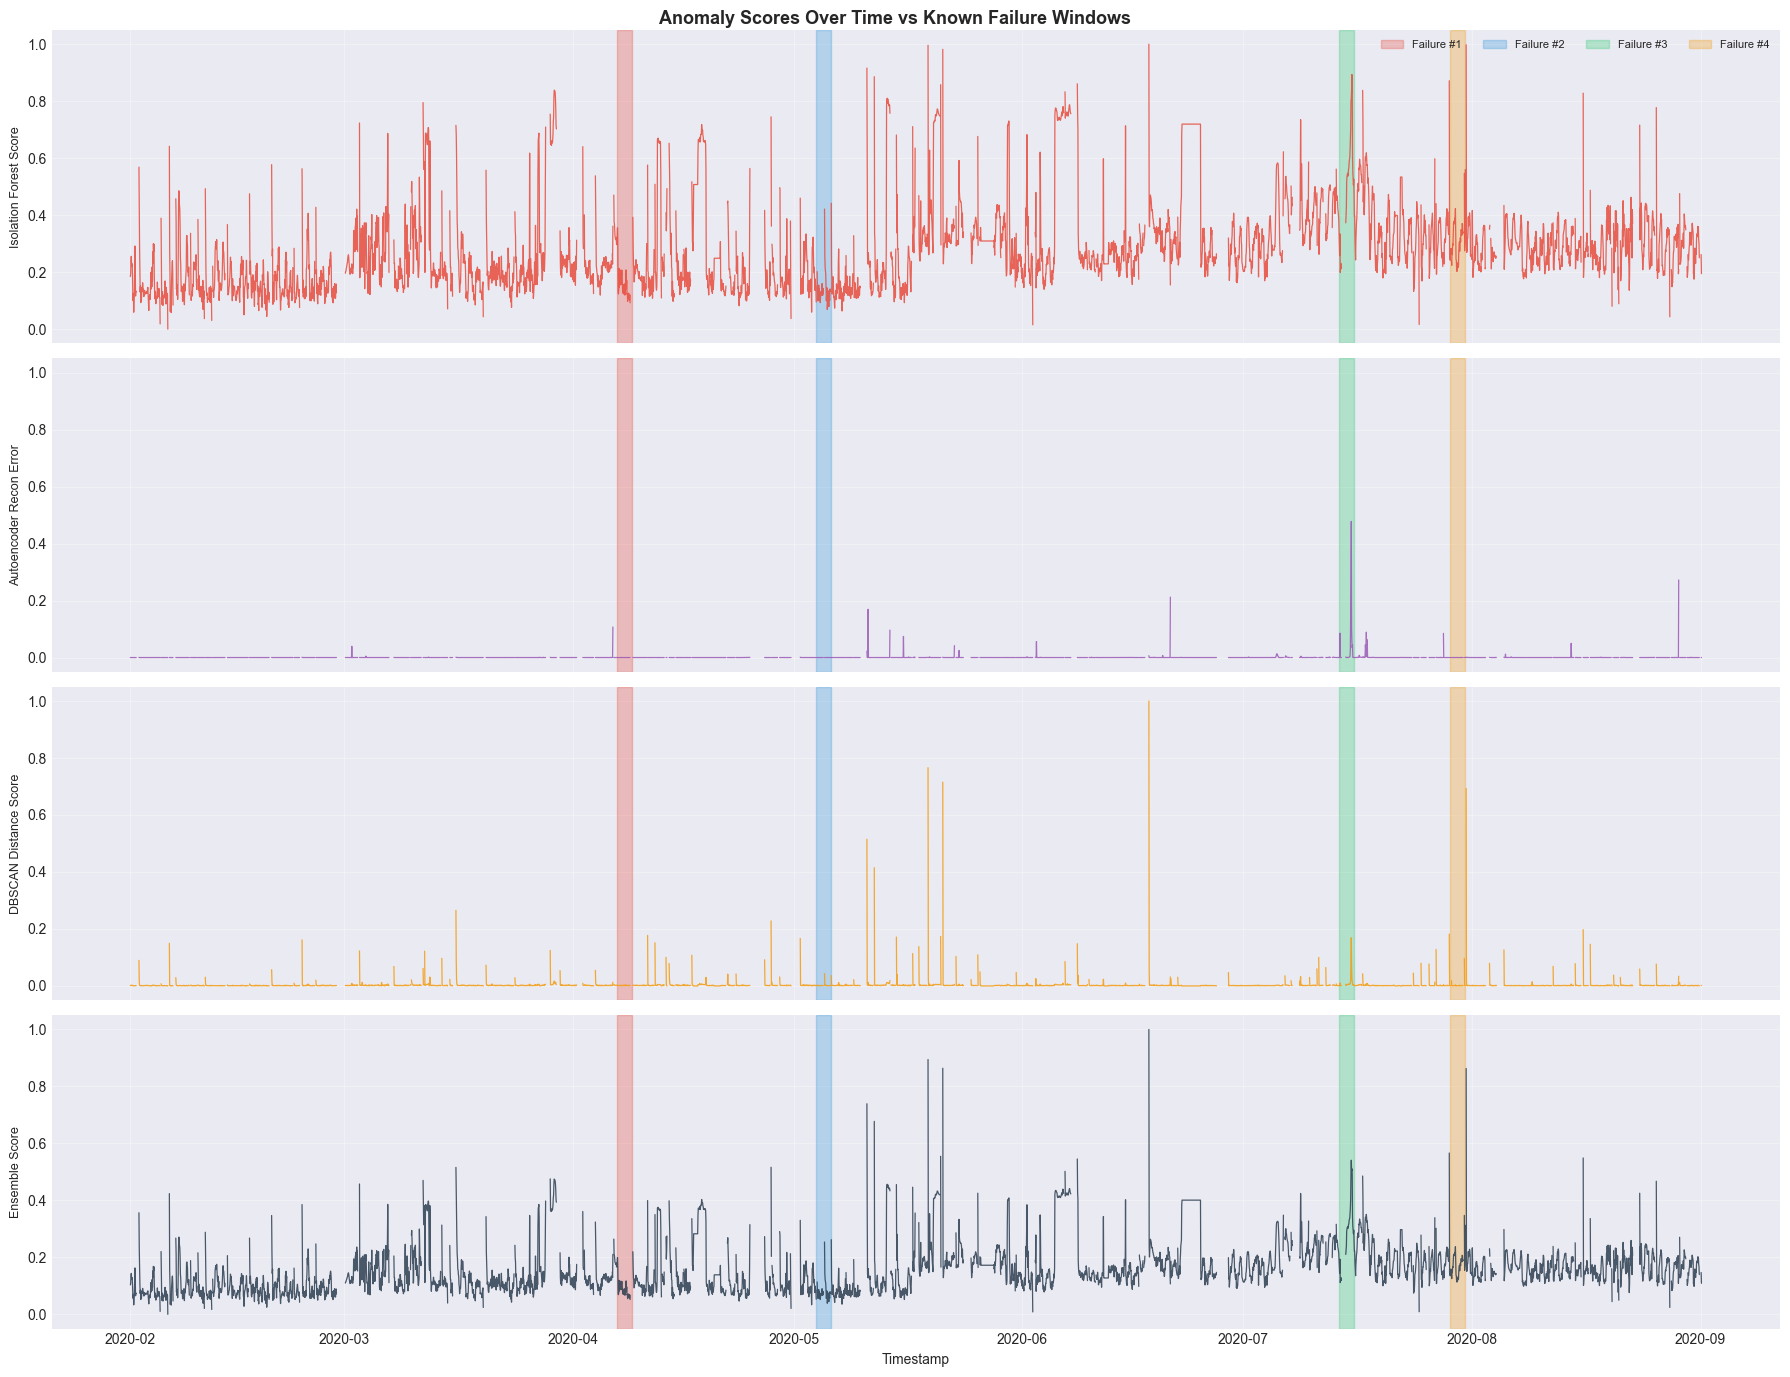

In [20]:
# Cell 14: Anomaly score time series — did models spike at failure windows?
df_hourly = df.set_index('full_timestamp').resample('1h').agg({
    'iso_score':      'mean',
    'ae_error':       'mean',
    'db_score':       'mean',
    'ensemble_score': 'mean',
    'ground_truth':   'max',
}).reset_index()

fig, axes = plt.subplots(4, 1, figsize=(18, 14), sharex=True)
score_info = [
    ('iso_score',      'Isolation Forest Score',  '#e74c3c'),
    ('ae_error',       'Autoencoder Recon Error', '#9b59b6'),
    ('db_score',       'DBSCAN Distance Score',   '#f39c12'),
    ('ensemble_score', 'Ensemble Score',           '#2c3e50'),
]
window_colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']

for ax, (col, label, clr) in zip(axes, score_info):
    s = df_hourly[col]
    s_norm = (s - s.min()) / max(s.max()-s.min(), 1e-9)
    ax.plot(df_hourly['full_timestamp'], s_norm, lw=0.9, color=clr, alpha=0.85)
    for i,(start,end,desc) in enumerate(FAILURE_WINDOWS):
        ax.axvspan(pd.Timestamp(start), pd.Timestamp(end),
                   alpha=0.3, color=window_colors[i],
                   label=f'Failure #{i+1}' if ax==axes[0] else '')
    ax.set_ylabel(label, fontsize=9); ax.grid(alpha=0.3)
    ax.set_ylim(-0.05, 1.05)
    if ax == axes[0]:
        ax.legend(loc='upper right', fontsize=8, ncol=4)

axes[-1].set_xlabel('Timestamp')
plt.suptitle('Anomaly Scores Over Time vs Known Failure Windows',
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


Computing PCA for visualisation ...
PCA explained variance: [0.67309766 0.24904295]


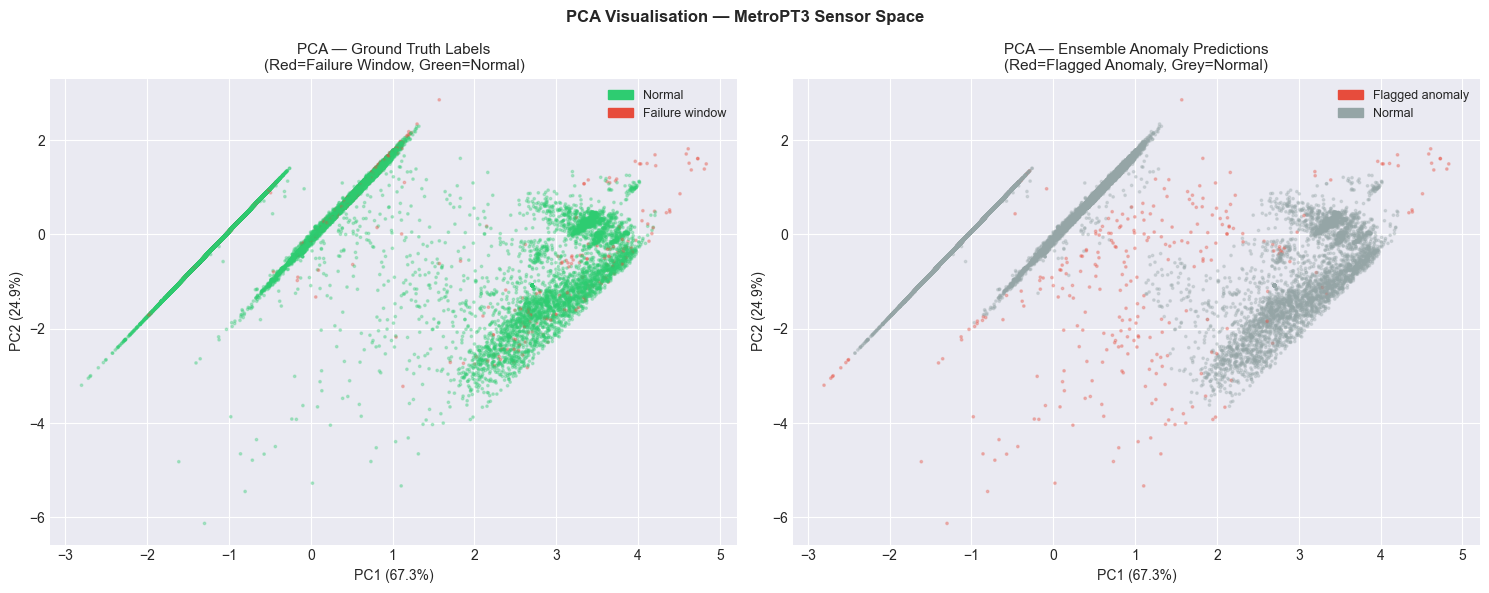

In [21]:
# Cell 15: PCA 2D — normal vs flagged anomalies
print("Computing PCA for visualisation ...")
sample_n   = min(30_000, len(df))
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(df), sample_n, replace=False)
X_sample   = X_all_sc[sample_idx]
gt_sample  = y_true[sample_idx]
ens_sample = df['ensemble_pred'].values[sample_idx]

pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d  = pca.fit_transform(X_sample)
print(f"PCA explained variance: {pca.explained_variance_ratio_}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Ground truth
scatter_clrs = np.where(gt_sample==1, '#e74c3c', '#2ecc71')
axes[0].scatter(X_2d[:,0], X_2d[:,1], c=scatter_clrs, alpha=0.3, s=3)
axes[0].set_title('PCA — Ground Truth Labels\n(Red=Failure Window, Green=Normal)',
                   fontsize=11)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
n_patch = mpatches.Patch(color='#2ecc71', label='Normal')
f_patch = mpatches.Patch(color='#e74c3c', label='Failure window')
axes[0].legend(handles=[n_patch, f_patch], fontsize=9)

# Ensemble prediction
scatter_clrs2 = np.where(ens_sample==1, '#e74c3c', '#95a5a6')
axes[1].scatter(X_2d[:,0], X_2d[:,1], c=scatter_clrs2, alpha=0.3, s=3)
axes[1].set_title('PCA — Ensemble Anomaly Predictions\n(Red=Flagged Anomaly, Grey=Normal)',
                   fontsize=11)
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
a_patch = mpatches.Patch(color='#e74c3c', label='Flagged anomaly')
n_patch2 = mpatches.Patch(color='#95a5a6', label='Normal')
axes[1].legend(handles=[a_patch, n_patch2], fontsize=9)

plt.suptitle('PCA Visualisation — MetroPT3 Sensor Space', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()


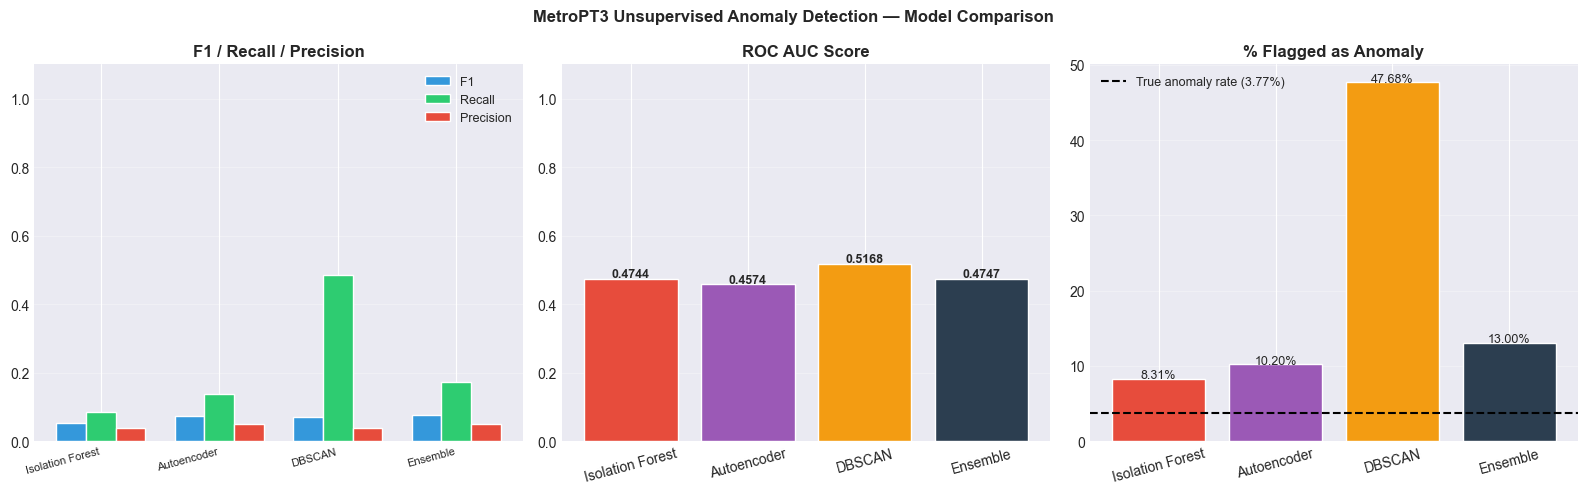


Full results table:
           model       f1  roc_auc  avg_precision   recall  precision  flagged_pct
Isolation Forest 0.052212 0.474372       0.040458 0.083571   0.037966     8.308459
     Autoencoder 0.074652 0.457449       0.060124 0.138219   0.051135    10.202525
          DBSCAN 0.071160 0.516775       0.044834 0.484989   0.038397    47.675332
        Ensemble 0.077406 0.474711       0.042218 0.172031   0.049938    13.002819


In [22]:
# Cell 16: Model comparison summary
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names   = results_df['model'].tolist()
model_palette = ['#e74c3c','#9b59b6','#f39c12','#2c3e50']

# F1 / Recall / Precision bar
metrics = ['f1','recall','precision']
x = np.arange(len(model_names)); width = 0.25
for i,(m,clr) in enumerate(zip(metrics,['#3498db','#2ecc71','#e74c3c'])):
    axes[0].bar(x+i*width, results_df[m], width, label=m.capitalize(),
                color=clr, edgecolor='white')
axes[0].set_xticks(x+width); axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=8)
axes[0].set_ylim(0,1.1); axes[0].set_title('F1 / Recall / Precision', fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3, axis='y')

# ROC AUC
bars = axes[1].bar(model_names, results_df['roc_auc'], color=model_palette, edgecolor='white')
for bar,val in zip(bars, results_df['roc_auc']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
axes[1].set_ylim(0,1.1); axes[1].set_title('ROC AUC Score', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15); axes[1].grid(alpha=0.3, axis='y')

# % flagged as anomaly
bars2 = axes[2].bar(model_names, results_df['flagged_pct'], color=model_palette, edgecolor='white')
for bar,val in zip(bars2, results_df['flagged_pct']):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                 f'{val:.2f}%', ha='center', fontsize=9)
axes[2].axhline(df['ground_truth'].mean()*100, color='black', ls='--', lw=1.5,
                label=f'True anomaly rate ({df["ground_truth"].mean()*100:.2f}%)')
axes[2].set_title('% Flagged as Anomaly', fontweight='bold')
axes[2].legend(fontsize=9); axes[2].tick_params(axis='x', rotation=15)
axes[2].grid(alpha=0.3, axis='y')

plt.suptitle('MetroPT3 Unsupervised Anomaly Detection — Model Comparison',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

print("\nFull results table:")
print(results_df[['model','f1','roc_auc','avg_precision','recall','precision','flagged_pct']].to_string(index=False))


In [ ]:
# Cell 17: Save JSON outputs
output_dir = Path("model_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

results_json = []
for _, r in results_df.iterrows():
    results_json.append({k: (round(float(v),6) if isinstance(v,(float,np.floating)) else v)
                         for k,v in r.items()})

descriptor = {
    "notebook":     "unsupervised_metropt3",
    "generated_at": datetime.utcnow().isoformat()+"Z",
    "task":         "unsupervised_anomaly_detection",
    "dataset":      "MetroPT3 — Porto Metro Air Production Unit",
    "note": ("No ground-truth labels used during training. "
             "Known failure windows applied post-hoc for evaluation only."),
    "total_rows":          int(len(df)),
    "training_rows":       int((df['full_timestamp'] < pd.Timestamp('2020-04-06')).sum()),
    "known_failure_rows":  int(df['ground_truth'].sum()),
    "known_failure_rate":  round(float(df['ground_truth'].mean()*100), 4),
    "failure_windows": [
        {"start":s,"end":e,"description":d}
        for s,e,d in FAILURE_WINDOWS
    ],
    "algorithms": ["Isolation Forest","Autoencoder (MLP)","DBSCAN","Ensemble"],
    "results": results_json,
    "best_model": results_df.sort_values('roc_auc', ascending=False).iloc[0]['model'],
}

with open(output_dir/"unsupervised_results.json","w") as f:
    json.dump(descriptor, f, indent=2)

results_df.to_csv(output_dir/"unsupervised_metrics.csv", index=False)

# Save anomaly flags for the full dataset
df[['measurement_id','full_timestamp','ground_truth',
    'iso_pred','ae_pred','db_pred','ensemble_pred','ensemble_score']]  .to_csv(output_dir/"metropt3_anomaly_flags.csv", index=False)

print("Saved:")
for fp in sorted(output_dir.glob("unsupervised*")) :
    print(f"  {fp.name}")
print("  metropt3_anomaly_flags.csv")
